In [ ]:
pip install numpy matplotlib scipy


Note: you may need to restart the kernel to use updated packages.


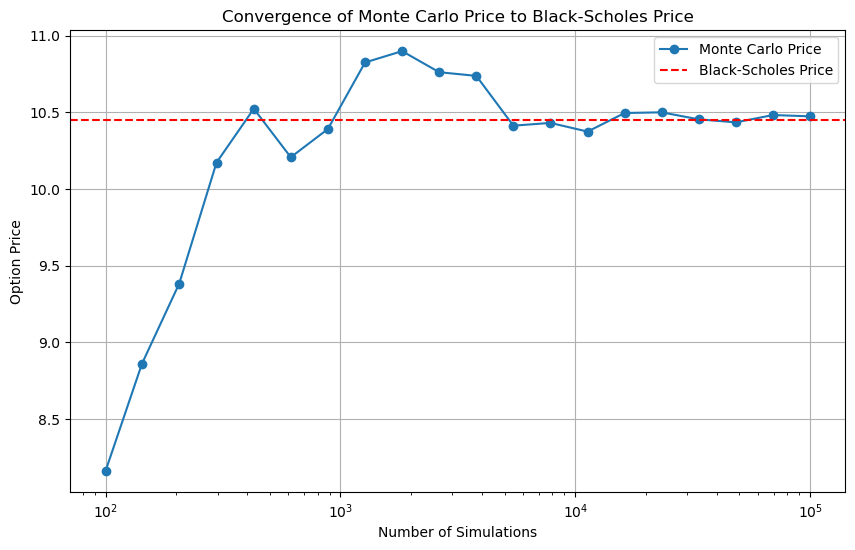

Black-Scholes Price (Call): 10.45
Monte Carlo Price (Call, 100000 simulations): 10.47


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# Step 1: Define Black-Scholes formula
def black_scholes(S, X, T, r, sigma, option_type="call"):
    d1 = (np.log(S / X) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    if option_type == "call":
        return S * norm.cdf(d1) - X * np.exp(-r * T) * norm.cdf(d2)
    elif option_type == "put":
        return X * np.exp(-r * T) * norm.cdf(-d2) - S * norm.cdf(-d1)

# Step 2: Monte Carlo simulation for option pricing
def monte_carlo_option_price(S, X, T, r, sigma, num_simulations, option_type="call"):
    np.random.seed(42)  # For reproducibility
    Z = np.random.standard_normal(num_simulations)
    ST = S * np.exp((r - 0.5 * sigma**2) * T + sigma * np.sqrt(T) * Z)
    if option_type == "call":
        payoffs = np.maximum(ST - X, 0)
    elif option_type == "put":
        payoffs = np.maximum(X - ST, 0)
    return np.exp(-r * T) * np.mean(payoffs)

# Step 3: Define parameters
S0 = 100  # Initial stock price
X = 100   # Strike price
T = 1     # Time to maturity (in years)
r = 0.05  # Risk-free rate
sigma = 0.2  # Volatility
num_simulations = 100000  # Number of Monte Carlo simulations

# Step 4: Calculate Black-Scholes and Monte Carlo prices
bs_price_call = black_scholes(S0, X, T, r, sigma, "call")
mc_price_call = monte_carlo_option_price(S0, X, T, r, sigma, num_simulations, "call")

# Step 5: Convergence visualization
simulation_sizes = np.logspace(2, 5, 20, dtype=int)  # Varying number of simulations
mc_prices = [monte_carlo_option_price(S0, X, T, r, sigma, n, "call") for n in simulation_sizes]

# Step 6: Plot results
plt.figure(figsize=(10, 6))
plt.plot(simulation_sizes, mc_prices, label="Monte Carlo Price", marker='o')
plt.axhline(y=bs_price_call, color="red", linestyle="--", label="Black-Scholes Price")
plt.xscale("log")
plt.xlabel("Number of Simulations")
plt.ylabel("Option Price")
plt.title("Convergence of Monte Carlo Price to Black-Scholes Price")
plt.legend()
plt.grid(True)
plt.show()

# Output Black-Scholes and Monte Carlo prices
print(f"Black-Scholes Price (Call): {bs_price_call:.2f}")
print(f"Monte Carlo Price (Call, {num_simulations} simulations): {mc_price_call:.2f}")
